In [1]:
from IPython.display import HTML, display

display(HTML(r"""
<h1>Vehicle AI Copilot — LangGraph Architecture</h1>
<p>Conceptual preview of the workflow implemented by <code>agent/graph.py</code>. The compiled LangGraph is rendered again after it is built.</p>
<div style="font-family:Arial,sans-serif; max-width:1050px; padding:18px; border:1px solid #ccd4df; border-radius:12px; background:#f8fafc;">
  <div style="display:flex; align-items:center; justify-content:center; gap:12px; flex-wrap:wrap;">
    <div style="padding:12px 18px; border-radius:8px; background:#334155; color:white;"><b>START</b><br>Driver question</div>
    <div style="font-size:28px;">→</div>
    <div style="padding:12px 18px; border-radius:8px; background:#0f766e; color:white;"><b>refresh_vehicle</b><br>Fresh SUMO state<br>Reset turn messages</div>
    <div style="font-size:28px;">→</div>
    <div style="padding:12px 18px; border-radius:8px; background:#2563eb; color:white;"><b>planner</b><br>Choose tools for this question</div>
  </div>
  <div style="text-align:center; font-size:25px; margin:12px 0;">↙ tool requested &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; final answer ↘</div>
  <div style="display:flex; justify-content:center; align-items:center; gap:40px; flex-wrap:wrap;">
    <div style="padding:12px 18px; border-radius:8px; background:#7c3aed; color:white; text-align:center;"><b>validate + tools</b><br>Run only required fresh tools</div>
    <div style="padding:12px 18px; border-radius:8px; background:#166534; color:white;"><b>final_answer → END</b><br>Use current-turn results only</div>
  </div>
  <div style="text-align:center; margin:10px 0; font-size:18px;">No old weather or route result is reused</div>
  <hr style="border:none; border-top:1px solid #ccd4df; margin:16px 0;">
  <div style="display:flex; justify-content:center; gap:14px; flex-wrap:wrap;">
    <div style="padding:9px 14px; border:1px solid #0f766e; border-radius:8px; background:white;"><b>SUMO</b> → motion, EV health, traffic</div>
    <div style="padding:9px 14px; border:1px solid #7c3aed; border-radius:8px; background:white;"><b>Open-Meteo</b> → current weather</div>
    <div style="padding:9px 14px; border:1px solid #7c3aed; border-radius:8px; background:white;"><b>Valhalla</b> → routes</div>
    <div style="padding:9px 14px; border:1px solid #64748b; border-radius:8px; background:white;"><b>Checkpointer</b> → current/previous vehicle state</div>
  </div>
</div>
<p>Run the remaining cells from top to bottom to start SUMO, build the graph, and chat with the copilot.</p>
"""))


## 1. Project and environment setup

This cell finds the project root automatically, loads `.env`, and checks the Groq key without printing the secret.


In [2]:
from pathlib import Path
import os
import sys
import shutil

from dotenv import load_dotenv

# Works whether the notebook is placed in the project root or a subfolder.
PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent:
    if (PROJECT_ROOT / "agent").is_dir() and (PROJECT_ROOT / "simulation").is_dir():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / "agent").is_dir():
    raise FileNotFoundError(
        "Could not find the project root. Put this notebook inside vehicle_ai_copilote/."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

load_dotenv(PROJECT_ROOT / ".env")

if not os.getenv("GROQ_API_KEY"):
    raise RuntimeError(
        "GROQ_API_KEY is missing. Add it to the project's .env file, then rerun this cell."
    )

print("Project root:", PROJECT_ROOT)
print("Groq API key: found")
print("SUMO executable:", shutil.which("sumo") or "NOT FOUND")

if shutil.which("sumo") is None:
    print(
        "WARNING: SUMO is not on PATH. The vehicle simulation will not start until "
        "the SUMO bin directory is available on PATH."
    )


Project root: C:\Users\Yessine\Desktop\vehicle_ai_copilote
Groq API key: found
SUMO executable: C:\Program Files (x86)\Eclipse\Sumo\bin\sumo.EXE


## 2. Start the SUMO EV simulation

This starts your existing `TripSimulator` and advances it one simulated second at a time so the vehicle visibly moves. Change `traffic_level`, SOC, or ambient temperature if you want a different test scenario.

Set `USE_GUI = True` if you want the SUMO window to open.


In [3]:
import time

from simulation.trip_simulator import TripSimulator

USE_GUI = True
PREVIEW_SECONDS = 60
GUI_DELAY_SECONDS = 0.10

# Safely close an older session when this notebook cell is rerun.
if "simulator" in globals():
    try:
        simulator.stop()
    except Exception:
        pass

simulator = TripSimulator(
    origin="Route El Ain, central Sfax",
    destination="North-east central Sfax",
    traffic_level="normal",       # "low", "normal", or "heavy"
    initial_soc_percent=80.0,
    ambient_temperature_c=25.0,
)

state = simulator.start(use_gui=USE_GUI)

print("Simulation started")
print("Initial speed:", state["movement"]["speed_kph"], "km/h")

# SUMO moves only when TraCI receives simulation steps.
for elapsed in range(1, PREVIEW_SECONDS + 1):
    state = simulator.step(1)
    if USE_GUI:
        time.sleep(GUI_DELAY_SECONDS)
    if elapsed % 10 == 0 or state["status"] != "running":
        movement = state["movement"]
        print(
            f"t={movement['elapsed_seconds']:.0f}s | "
            f"speed={movement['speed_kph']:.1f} km/h | "
            f"progress={movement['trip_progress_percent']:.1f}%"
        )
    if state["status"] != "running":
        break

print("Status:", state["status"])
print("Battery SOC:", state["ev"]["battery_soc_percent"], "%")
print("Traffic level:", state["traffic"].get("traffic_level"))


Simulation started
Initial speed: 0.0 km/h
t=11s | speed=59.9 km/h | progress=5.1%
t=21s | speed=84.2 km/h | progress=14.4%
t=31s | speed=35.2 km/h | progress=21.0%
t=41s | speed=52.3 km/h | progress=28.8%
t=51s | speed=36.9 km/h | progress=34.7%
t=61s | speed=24.9 km/h | progress=41.6%
Status: running
Battery SOC: 79.87988095238096 %
Traffic level: normal


## 3. Build the actual LangGraph copilot

This calls your project's `agent.graph.build_copilot_graph(simulator)`, then uses LangGraph's built-in renderer to display the actual compiled workflow.


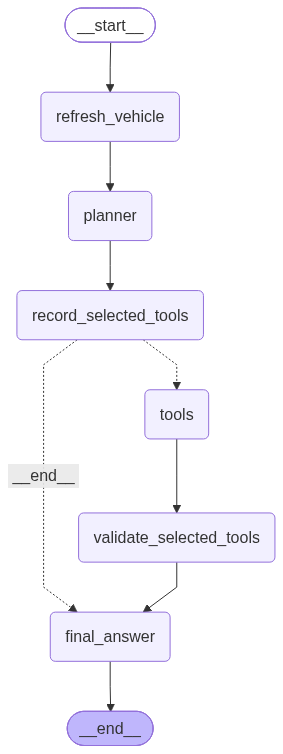

LangGraph copilot ready.


In [4]:
from IPython.display import Image, display

from agent.graph import build_copilot_graph

copilot = build_copilot_graph(simulator)

try:
    display(Image(copilot.get_graph().draw_mermaid_png()))
except Exception as exc:
    print("PNG rendering was unavailable; Mermaid source follows.")
    print(copilot.get_graph().draw_mermaid())
    print("Renderer details:", exc)

print("LangGraph copilot ready.")


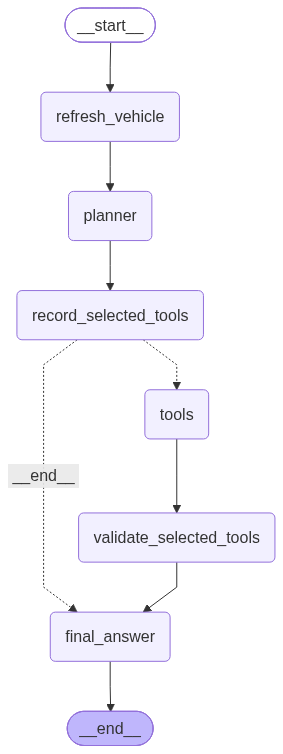

LangGraph copilot ready.


In [5]:
from agent.graph import build_copilot_graph
from IPython.display import Image, display

copilot = build_copilot_graph(simulator)

display(
    Image(
        copilot.get_graph().draw_mermaid_png()
    )
)

print("LangGraph copilot ready.")

## 4. Chat helper

`ask_copilot()` keeps structured vehicle-state memory through LangGraph's checkpointer. When a question requires weather or routing, that tool must run again in the current turn. Old tool messages are reset before the next question.


In [6]:
from uuid import uuid4

from IPython.display import Markdown, display
from langchain_core.messages import AIMessage, ToolMessage

THREAD_ID = f"notebook-{uuid4().hex[:8]}"


def _message_text(content) -> str:
    """Convert common LangChain message content formats to readable text."""
    if isinstance(content, str):
        return content
    if isinstance(content, list):
        parts = []
        for item in content:
            if isinstance(item, str):
                parts.append(item)
            elif isinstance(item, dict) and isinstance(item.get("text"), str):
                parts.append(item["text"])
        if parts:
            return "\n".join(parts)
    return str(content)


def reset_chat() -> None:
    """Start a fresh LangGraph conversation without restarting SUMO."""
    global THREAD_ID
    THREAD_ID = f"notebook-{uuid4().hex[:8]}"
    print("Chat reset. New thread:", THREAD_ID)


def ask_copilot(
    question: str,
    *,
    show_trace: bool = True,
    show_tool_results: bool = False,
):
    """Send one message through the complete LangGraph agent/tool workflow."""
    question = question.strip()
    if not question:
        raise ValueError("Question cannot be empty.")

    display(Markdown(f"**Driver:** {question}"))

    config = {"configurable": {"thread_id": THREAD_ID}}
    final_ai_message = None

    for update in copilot.stream(
        {"question": question},
        config=config,
        stream_mode="updates",
    ):
        for node_name, node_state in update.items():
            if not isinstance(node_state, dict):
                continue

            turn_messages = node_state.get("turn_messages", [])

            # Nodes return the complete message list for this turn.
            # Inspect only messages produced by the current node.
            if node_name in {"planner", "final_answer"}:
                new_messages = turn_messages[-1:]
            elif node_name == "tools":
                new_messages = []
                for candidate in reversed(turn_messages):
                    if not isinstance(candidate, ToolMessage):
                        break
                    new_messages.append(candidate)
                new_messages.reverse()
            else:
                new_messages = []

            for message in new_messages:
                if isinstance(message, AIMessage):
                    if message.tool_calls:
                        if show_trace:
                            for call in message.tool_calls:
                                print(
                                    f"[LLM selected tool] {call['name']} "
                                    f"args={call.get('args', {})}"
                                )
                    else:
                        final_ai_message = message

                elif isinstance(message, ToolMessage):
                    if show_trace:
                        print(f"[Tool completed] {message.name or 'tool'}")
                    if show_tool_results:
                        print(_message_text(message.content))

    if final_ai_message is None:
        raise RuntimeError("The copilot did not return a final AI response.")

    answer = _message_text(final_ai_message.content)
    display(Markdown("**Copilot:**"))
    display(Markdown(answer))
    return final_ai_message


## 5. First end-to-end tests

Run these one at a time. They are designed to force each major tool path.


In [7]:
ask_copilot("What is the weather in Sfax right now?")


**Driver:** What is the weather in Sfax right now?

[LLM selected tool] weather_tool args={'city': 'Sfax'}
[Tool completed] weather_tool


**Copilot:**

Current conditions in Sfax:

- **Temperature:** 30.8 °C  
- **Humidity:** 42 %  
- **Precipitation:** none (0 mm)  
- **Wind:** 10.9 km/h  
- **Sky:** Overcast  

Stay cool and drive safely!

AIMessage(content='Current conditions in Sfax:\n\n- **Temperature:** 30.8\u202f°C  \n- **Humidity:** 42\u202f%  \n- **Precipitation:** none (0\u202fmm)  \n- **Wind:** 10.9\u202fkm/h  \n- **Sky:** Overcast  \n\nStay cool and drive safely!', additional_kwargs={'reasoning_content': 'We have weather data: temperature 30.8°C, humidity 42%, no precipitation, wind 10.9 km/h, overcast. Need to answer driver clearly and concisely. Also can mention battery status maybe? The question only asks weather. Provide answer.'}, response_metadata={'token_usage': {'completion_tokens': 130, 'prompt_tokens': 1264, 'total_tokens': 1394, 'completion_time': 0.274098004, 'completion_tokens_details': {'reasoning_tokens': 57}, 'prompt_time': 0.236044567, 'prompt_tokens_details': None, 'queue_time': 0.138450207, 'total_time': 0.510142571}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_4200b3f836', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id

In [8]:
ask_copilot("I want to drive from Sfax to Tunis. How far is it and approximately how long will it take?")


**Driver:** I want to drive from Sfax to Tunis. How far is it and approximately how long will it take?

[LLM selected tool] route_tool args={'destination': 'Tunis', 'origin': 'Sfax'}
[Tool completed] route_tool


**Copilot:**

**Sfax → Tunis**

- **Distance:** ≈ 270 km  
- **Estimated travel time:** ≈ 196 minutes (about 3 hours 15 minutes) under normal traffic conditions.  

The route mainly follows highways and includes toll sections. With your Hyundai IONIQ 5’s current state of charge (~80 % – roughly 419 km of range), the trip can be completed without needing to recharge. Safe driving!

AIMessage(content='**Sfax\u202f→\u202fTunis**\n\n- **Distance:**\u202f≈\u202f270\u202fkm  \n- **Estimated travel time:**\u202f≈\u202f196\u202fminutes (about\u202f3\u202fhours\u202f15\u202fminutes) under normal traffic conditions.  \n\nThe route mainly follows highways and includes toll sections. With your Hyundai IONIQ\u202f5’s current state of charge (~80\u202f% – roughly 419\u202fkm of range), the trip can be completed without needing to recharge. Safe driving!', additional_kwargs={'reasoning_content': 'We have route_tool result: distance 270.08 km, duration 196.4 minutes (~3h16m). Need to answer driver. Also note current vehicle state: battery SOC ~79.9%, estimated remaining range 419 km, so sufficient. Provide approximate travel time, maybe adjust for traffic (normal). Provide note about highway and toll. Also mention that current trip is only 1.8 km to NE Sfax, but they want new route. Provide answer concisely.'}, response_metadata={'token_usage': {'completion_tokens': 209, 'promp

In [9]:
# The graph must use the active simulator location (Sfax), never invent an origin.
ask_copilot("Can I reach Hammamet?")


**Driver:** Can I reach Hammamet?

[LLM selected tool] route_tool args={'destination': 'Hammamet', 'origin': 'Sfax'}
[Tool completed] route_tool


**Copilot:**

**Yes – you have enough charge to reach Hammamet.**

| Item | Value |
|------|-------|
| **Current SOC** | ≈ 79.9 % (≈ 67 kWh usable) |
| **Distance to Hammamet** | 211.6 km (via highway) |
| **Typical consumption** | ≈ 16 kWh / 100 km (reference) |
| **Estimated energy needed** | ≈ 33.9 kWh |
| **Projected SOC after arrival** | ≈ 39 % (≈ 33 kWh left) |
| **Estimated travel time** | ≈ 2 h 28 min (146.9 min) |
| **Tolls** | Yes (highway) |
| **Charging needed en‑route** | No – you’ll still have roughly 40 % battery on arrival. |

**What to keep in mind**

* The estimate uses the reference consumption (16 kWh/100 km). Real‑world use can be a bit higher if traffic, climate control, or aggressive driving increase demand.  
* You’ll be on a highway for most of the trip, so keep an eye on speed and any upcoming toll plazas.  
* If you plan to drive further after Hammamet, consider topping up while you’re there; you’ll still have a comfortable margin.

Safe travels to Hammamet! 🚗⚡️

AIMessage(content='**Yes – you have enough charge to reach Hammamet.**\n\n| Item | Value |\n|------|-------|\n| **Current SOC** |\u202f≈\u202f79.9\u202f% (≈\u202f67\u202fkWh usable) |\n| **Distance to Hammamet** |\u202f211.6\u202fkm (via highway) |\n| **Typical consumption** |\u202f≈\u202f16\u202fkWh\u202f/\u202f100\u202fkm (reference) |\n| **Estimated energy needed** |\u202f≈\u202f33.9\u202fkWh |\n| **Projected SOC after arrival** |\u202f≈\u202f39\u202f% (≈\u202f33\u202fkWh left) |\n| **Estimated travel time** |\u202f≈\u202f2\u202fh\u202f28\u202fmin (146.9\u202fmin) |\n| **Tolls** |\u202fYes (highway) |\n| **Charging needed en‑route** |\u202fNo – you’ll still have roughly 40\u202f% battery on arrival. |\n\n**What to keep in mind**\n\n* The estimate uses the reference consumption (16\u202fkWh/100\u202fkm). Real‑world use can be a bit higher if traffic, climate control, or aggressive driving increase demand.  \n* You’ll be on a highway for most of the trip, so keep an eye on speed and a

In [10]:
ask_copilot("How is my car doing right now? Summarize speed, battery, health, and traffic.")


**Driver:** How is my car doing right now? Summarize speed, battery, health, and traffic.

**Copilot:**

**Current vehicle snapshot (as of the latest simulation update):**

| Category | Details |
|----------|---------|
| **Speed** | 24.9 km/h (≈15.5 mph) |
| **Battery** | • State‑of‑charge: **79.9 %** (≈ 67 kWh of the 84 kWh pack) <br>• Estimated remaining range: **≈ 419 km** (reference‑based) <br>• Not low, not charging |
| **Health** | • Overall status: **normal** (no warnings) <br>• Battery SOH: **≈ 100 %** <br>• Battery temperature: **25.7 °C** <br>• Motor temperature: **29 °C** <br>• Inverter temperature: **28 °C** <br>• Tire pressures: **≈ 32 psi** on all wheels (temperatures ~25 °C) |
| **Traffic (simulated Sfax network)** | • Scenario: **normal** <br>• Congestion: **none** (is_congested = false) <br>• Average network speed: **36.9 km/h** <br>• Average delay: **0 s** |

**Summary:** Your Hyundai IONIQ 5 is moving at a modest 25 km/h, the battery is healthy with about 80 % charge and a generous remaining range, all vehicle systems report normal status, and traffic around you is flowing freely with no delays.

AIMessage(content='**Current vehicle snapshot (as of the latest simulation update):**\n\n| Category | Details |\n|----------|---------|\n| **Speed** | 24.9\u202fkm/h (≈15.5\u202fmph) |\n| **Battery** | • State‑of‑charge: **79.9\u202f%** (≈\u202f67\u202fkWh of the 84\u202fkWh pack) <br>• Estimated remaining range: **≈\u202f419\u202fkm** (reference‑based) <br>• Not low, not charging |\n| **Health** | • Overall status: **normal** (no warnings) <br>• Battery SOH: **≈\u202f100\u202f%** <br>• Battery temperature: **25.7\u202f°C** <br>• Motor temperature: **29\u202f°C** <br>• Inverter temperature: **28\u202f°C** <br>• Tire pressures: **≈\u202f32\u202fpsi** on all wheels (temperatures ~25\u202f°C) |\n| **Traffic (simulated Sfax network)** | • Scenario: **normal** <br>• Congestion: **none** (is_congested\u202f=\u202ffalse) <br>• Average network speed: **36.9\u202fkm/h** <br>• Average delay: **0\u202fs** |\n\n**Summary:** Your Hyundai IONIQ\u202f5 is moving at a modest 25\u202fkm/h, the battery 

### Multi-tool test

This is useful for checking whether the LLM can combine different project capabilities in a single answer.


In [11]:
ask_copilot(
    "Check the current weather in Sfax and my current vehicle state. "
    "Is there anything important I should know before continuing the trip?"
)


**Driver:** Check the current weather in Sfax and my current vehicle state. Is there anything important I should know before continuing the trip?

[LLM selected tool] weather_tool args={'city': 'Sfax'}
[Tool completed] weather_tool


**Copilot:**

**Current weather in Sfax**  
- **Condition:** Overcast  
- **Temperature:** 30.8 °C (warm)  
- **Humidity:** 42 %  
- **Wind:** 10.9 km/h from the west‑south‑west (light)  
- **Precipitation:** 0 mm (dry)  

**Your vehicle right now**  

| Parameter | Value | Comment |
|-----------|-------|---------|
| **Status** | Running, moving at 24.9 km/h | Normal operation |
| **Battery SOC** | 79.9 % (≈ 67 kWh usable) | Plenty of charge |
| **Estimated remaining range** | ~ 419 km | Far exceeds the ~1 km left on today’s trip |
| **Battery temperature** | 25.7 °C | Well within safe limits |
| **Motor temperature** | 29 °C | Normal |
| **Tire pressures** | 32 psi (all wheels) | Correct |
| **Health warnings** | None | System reports “normal” |
| **Trip progress** | 41.6 % (0.76 km travelled) | About 1 km remaining to the destination |
| **Traffic** | Normal, no congestion | No expected delays |

**Anything important to know?**  

- **Weather:** The overcast sky and light wind won’t affect handling, but the warm temperature means the cabin may heat up quickly. Keep the climate control on a comfortable setting; the battery is staying cool, so there’s no risk of overheating.  
- **Battery & range:** With ~80 % SOC and an estimated 419 km of range, you have more than enough energy to finish the short 1.8 km trip and any further driving you may do afterward.  
- **Vehicle health:** All systems are nominal, tire pressures are balanced, and there are no warnings.  
- **Driving:** You’re currently decelerating slightly (‑0.39 m/s²). If you want to maintain a smoother speed, a gentle throttle input will keep you around the current 25 km/h, which is close to the average traffic speed (≈ 37 km/h).  

**Bottom line:** Conditions are good. No immediate concerns—feel free to continue the trip. Safe driving!

AIMessage(content='**Current weather in Sfax**  \n- **Condition:** Overcast  \n- **Temperature:**\u202f30.8\u202f°C (warm)  \n- **Humidity:**\u202f42\u202f%  \n- **Wind:**\u202f10.9\u202fkm/h from the west‑south‑west (light)  \n- **Precipitation:**\u202f0\u202fmm (dry)  \n\n**Your vehicle right now**  \n\n| Parameter | Value | Comment |\n|-----------|-------|---------|\n| **Status** | Running, moving at 24.9\u202fkm/h | Normal operation |\n| **Battery SOC** | 79.9\u202f% (≈\u202f67\u202fkWh usable) | Plenty of charge |\n| **Estimated remaining range** | ~\u202f419\u202fkm | Far exceeds the ~1\u202fkm left on today’s trip |\n| **Battery temperature** | 25.7\u202f°C | Well within safe limits |\n| **Motor temperature** | 29\u202f°C | Normal |\n| **Tire pressures** | 32\u202fpsi (all wheels) | Correct |\n| **Health warnings** | None | System reports “normal” |\n| **Trip progress** | 41.6\u202f% (0.76\u202fkm travelled) | About 1\u202fkm remaining to the destination |\n| **Traffic** | Norma

## 6. Advance the simulated vehicle

LangGraph refreshes the current SUMO vehicle state automatically at the beginning of every question. Advance SUMO, then ask a comparison question to verify that the graph retains the previous structured snapshot and reads new telemetry.


In [12]:
def advance_vehicle(seconds: float = 30.0, gui_delay_seconds: float = 0.10):
    if seconds <= 0:
        raise ValueError("seconds must be greater than zero")

    remaining = float(seconds)
    state = simulator.get_state()
    while remaining > 0 and state["status"] == "running":
        step_seconds = min(1.0, remaining)
        state = simulator.step(step_seconds)
        remaining -= step_seconds
        if USE_GUI and gui_delay_seconds:
            time.sleep(gui_delay_seconds)

    movement = state["movement"]
    ev = state["ev"]
    traffic = state["traffic"]

    print(f"Advanced simulation by {seconds:g} s")
    print("Status:", state["status"])
    print("Speed:", movement["speed_kph"], "km/h")
    print("Progress:", movement["trip_progress_percent"], "%")
    print("SOC:", ev["battery_soc_percent"], "%")
    print("Remaining range:", ev["estimated_remaining_range_km"], "km")
    print("Traffic level:", traffic.get("traffic_level"))
    return state


advance_vehicle(60)


Advanced simulation by 60 s
Status: running
Speed: 51.46 km/h
Progress: 82.28 %
SOC: 79.74439285714286 %
Remaining range: 157.89038575361033 km
Traffic level: normal


{'status': 'running',
 'simulation_backend': 'sumo',
 'origin': {'name': 'Route El Ain, central Sfax',
  'city': 'Sfax',
  'country': 'Tunisia',
  'latitude': 34.7518952,
  'longitude': 10.7296079},
 'destination': {'name': 'North-east central Sfax',
  'city': 'Sfax',
  'country': 'Tunisia',
  'latitude': 34.762,
  'longitude': 10.746},
 'route': {'distance_km': 1.824,
  'duration_minutes': None,
  'uses_highway': False,
  'has_toll': False,
  'has_ferry': False},
 'movement': {'speed_kph': 51.46,
  'acceleration_mps2': -0.088,
  'position': {'latitude': 34.7571454,
   'longitude': 10.7406814,
   'x': 5370.17,
   'y': 2530.22},
  'current_road': 'نهج 796',
  'road_name': 'نهج 796',
  'road_id': ':6539269064_3',
  'lane_id': ':6539269064_3_0',
  'lane_position_m': 6.86,
  'angle_deg': 53.65,
  'waiting_time_s': 0.0,
  'elapsed_seconds': 121.0,
  'simulation_time_s': 121.0,
  'travelled_distance_km': 1.501,
  'trip_progress_percent': 82.28},
 'ev': {'model': 'Hyundai IONIQ 5 Long Range R

In [13]:
ask_copilot(
    "My simulation has advanced. What changed in my current vehicle condition and traffic situation and Estimated remaining range "
)


**Driver:** My simulation has advanced. What changed in my current vehicle condition and traffic situation and Estimated remaining range

**Copilot:**

**Vehicle‑condition changes (since the last snapshot)**  

| Parameter | Earlier (≈ 61 s) | Now (≈ 121 s) | What changed |
|-----------|----------------|--------------|--------------|
| **Speed** | 24.9 km/h | **51.5 km/h** | Accelerated – speed roughly doubled. |
| **Location** | 34.753 ° N, 10.735 ° E | 34.757 ° N, 10.741 ° E | Moved ~0.75 km north‑east along “نهج 796”. |
| **Trip progress** | 41.6 % | **82.3 %** | You’re now past the halfway point of the 1.82 km route. |
| **Elapsed time** | 61 s | **121 s** | Simulation time advanced by 60 s. |
| **Travelled distance** | 0.76 km | **1.50 km** | Added ~0.74 km of driving. |
| **Acceleration** | –0.39 m/s² (decelerating) | –0.09 m/s² (almost steady) | Deceleration eased; vehicle is now cruising. |
| **Battery energy** | 67.10 kWh | **66.99 kWh** | Small drop of ~0.11 kWh. |
| **State‑of‑Charge (SOC)** | 79.88 % | **79.74 %** | SOC fell by ~0.14 percentage points. |
| **Instant consumption** | –0.74 Wh / s (regeneration) | **+0.55 Wh / s** (consumption) | Switched from net regen to drawing power. |
| **Observed consumption** | – | **42.4 kWh/100 km** | Real‑world draw is much higher than the reference 16 kWh/100 km. |
| **Estimated remaining range** | **≈ 419 km** (reference‑based) | **≈ 158 km** (observed‑based) | Range fell dramatically because the car is now using energy at ~42 kWh/100 km. |

**Traffic‑situation changes (simulation‑wide)**  

| Metric | Earlier | Now | Change |
|--------|---------|-----|--------|
| **Average speed of traffic** | 36.9 km/h | **41.9 km/h** | Traffic is moving a bit faster. |
| **Congestion index** | 0 % | **3.1 %** | Slight increase, but still very light congestion. |
| **Is congested?** | No | No | No congestion flag triggered. |
| **Average delay per vehicle** | 0.0 s | **0.09 s** | Negligible extra delay. |
| **Active vehicles in the simulation** | 17 | 32 | More vehicles are now present, but they’re not causing jams. |

**Bottom line**

- Your car has accelerated, covered roughly another 0.75 km, and is now cruising at about 51 km/h.  
- Battery SOC dipped only a hair, but because instantaneous consumption jumped to ~0.55 Wh / s (≈ 42 kWh/100 km), the **estimated remaining range fell from ~419 km (reference estimate) to ~158 km (observed estimate)**.  
- Traffic around you is a bit faster and includes more vehicles, yet congestion remains minimal.

AIMessage(content='**Vehicle‑condition changes (since the last snapshot)**  \n\n| Parameter | Earlier (≈\u202f61\u202fs) | Now (≈\u202f121\u202fs) | What changed |\n|-----------|----------------|--------------|--------------|\n| **Speed** | 24.9\u202fkm/h | **51.5\u202fkm/h** | Accelerated – speed roughly doubled. |\n| **Location** |\u202f34.753\u202f°\u202fN,\u202f10.735\u202f°\u202fE |\u202f34.757\u202f°\u202fN,\u202f10.741\u202f°\u202fE | Moved ~0.75\u202fkm north‑east along “نهج\u202f796”. |\n| **Trip progress** | 41.6\u202f% | **82.3\u202f%** | You’re now past the halfway point of the 1.82\u202fkm route. |\n| **Elapsed time** | 61\u202fs | **121\u202fs** | Simulation time advanced by 60\u202fs. |\n| **Travelled distance** | 0.76\u202fkm | **1.50\u202fkm** | Added ~0.74\u202fkm of driving. |\n| **Acceleration** | –0.39\u202fm/s² (decelerating) | –0.09\u202fm/s² (almost steady) | Deceleration eased; vehicle is now cruising. |\n| **Battery energy** | 67.10\u202fkWh | **66.99\u202fkWh

## 7. Continuous interactive chat

Run the next cell to define a terminal-like chat inside Jupyter. After the prompt helper cell is loaded, call `start_chat()` manually.

Commands:

- `/step 30` - advance SUMO by 30 seconds
- `/state` - ask the copilot for the current vehicle state
- `/prompts` - list saved test prompts
- `/test route_hammamet` - run a saved prompt by name
- `/reset` - start a new LLM conversation
- `/quit` - leave the chat loop


In [14]:
def start_chat() -> None:
    print("Vehicle AI Copilot ready.")
    print("Commands: /step <seconds>, /state, /reset, /prompts, /test <name>, /quit")

    while True:
        try:
            question = input("\nDriver: ").strip()
        except (EOFError, KeyboardInterrupt):
            print("\nChat ended.")
            break

        if not question:
            continue

        command = question.lower()

        if command in {"/quit", "quit", "exit"}:
            print("Chat ended.")
            break

        if command == "/reset":
            reset_chat()
            continue

        if command == "/state":
            ask_copilot(TEST_PROMPTS["vehicle_state"])
            continue

        if command == "/prompts":
            list_test_prompts()
            continue

        if command.startswith("/test"):
            parts = question.split(maxsplit=1)
            if len(parts) != 2:
                print("Usage: /test <prompt_name>")
                list_test_prompts()
                continue
            run_test_prompt(parts[1].strip())
            continue

        if command.startswith("/step"):
            parts = question.split(maxsplit=1)
            seconds = 30.0
            if len(parts) == 2:
                try:
                    seconds = float(parts[1])
                except ValueError:
                    print("Usage: /step <seconds>")
                    continue
            advance_vehicle(seconds)
            continue

        ask_copilot(question)


# Run start_chat() manually when you want continuous chat.
# start_chat()


## 8. Useful prompts for project testing

The next cell defines reusable prompt names, so you do not have to retype long questions.

Examples:

```python
run_test_prompt("route_hammamet")
run_test_prompt("safe_tunis")
run_test_prompt("memory_compare")
```

Inside `start_chat()`, you can also type:

```text
/prompts
/test route_hammamet
/test safe_tunis
```


In [15]:
TEST_PROMPTS = {
    "vehicle_state": "How is my car doing right now? Summarize speed, battery, health, and traffic.",
    "vehicle_warnings": "Do I have any vehicle-health or battery warnings right now?",
    "memory_compare": "Compare my current EV battery, speed, traffic congestion, trip progress, and estimated range with the previous state. Tell me only what changed.",
    "weather_sfax": "What is the weather in Sfax right now?",
    "weather_hammamet": "What is the weather in Hammamet right now?",
    "route_hammamet": "Can I reach Hammamet?",
    "route_tunis": "How far is Tunis from my current location by car, and how long will it take?",
    "route_sousse": "How long will it take to drive to Sousse from my current location?",
    "safe_hammamet": "Can I safely drive to Hammamet right now? Use fresh route and weather information.",
    "safe_tunis": "Can I drive to Tunis with my current battery and current weather?",
    "anti_memory_1": "Can I reach Hammamet?",
    "anti_memory_2": "Can I reach Tunis?",
}


def list_test_prompts() -> None:
    print("Available test prompts:")
    for name, prompt in TEST_PROMPTS.items():
        print(f"- {name}: {prompt}")


def run_test_prompt(name: str):
    try:
        prompt = TEST_PROMPTS[name]
    except KeyError:
        print(f"Unknown prompt: {name}")
        list_test_prompts()
        return None

    return ask_copilot(prompt)


list_test_prompts()


Available test prompts:
- vehicle_state: How is my car doing right now? Summarize speed, battery, health, and traffic.
- vehicle_warnings: Do I have any vehicle-health or battery warnings right now?
- memory_compare: Compare my current EV battery, speed, traffic congestion, trip progress, and estimated range with the previous state. Tell me only what changed.
- weather_sfax: What is the weather in Sfax right now?
- weather_hammamet: What is the weather in Hammamet right now?
- route_hammamet: Can I reach Hammamet?
- route_tunis: How far is Tunis from my current location by car, and how long will it take?
- route_sousse: How long will it take to drive to Sousse from my current location?
- safe_hammamet: Can I safely drive to Hammamet right now? Use fresh route and weather information.
- safe_tunis: Can I drive to Tunis with my current battery and current weather?
- anti_memory_1: Can I reach Hammamet?
- anti_memory_2: Can I reach Tunis?


In [16]:
run_test_prompt("vehicle_state")


**Driver:** How is my car doing right now? Summarize speed, battery, health, and traffic.

**Copilot:**

**Current vehicle status (as of the latest simulation snapshot):**

| Category | Details |
|----------|---------|
| **Speed / Motion** | • Speed: **51 km/h** (51.46 km/h) <br>• On road “نهج 796” in central Sfax <br>• Trip is **82 %** complete, having traveled **1.5 km** so far |
| **Battery** | • State‑of‑Charge: **79.7 %** (≈ 67 kWh of the 84 kWh pack) <br>• Estimated remaining range: **≈ 158 km** (based on observed consumption) <br>• Current consumption: **0.55 Wh / s** (≈ 42 kWh/100 km) – higher than the reference 16 kWh/100 km, typical for city driving <br>• Not low‑battery, not charging |
| **Health** | • Overall status: **normal** <br>• Battery SOH: **≈ 100 %** <br>• Temperatures – Battery: **26 °C**, Motor: **31 °C**, Inverter: **30 °C** (all normal) <br>• Tire pressures: **≈ 32 psi** on all wheels; tire temps ~ 26 °C <br>• No warnings reported |
| **Traffic (simulated)** | • Scenario: **normal** <br>• Average traffic speed nearby: **≈ 42 km/h** <br>• Congestion index: **3 %** (light traffic) <br>• No significant delays or congestion detected |

**Summary:** Your Hyundai IONIQ 5 is cruising at about 51 km/h on a city road with a healthy battery (≈ 80 % SOC, ~158 km range left). All health metrics are normal, and traffic conditions are light, so you’re driving under comfortable, normal conditions.

AIMessage(content='**Current vehicle status (as of the latest simulation snapshot):**\n\n| Category | Details |\n|----------|---------|\n| **Speed / Motion** | • Speed: **51\u202fkm/h** (51.46\u202fkm/h) <br>• On road “نهج\u202f796” in central Sfax <br>• Trip is **82\u202f%** complete, having traveled **1.5\u202fkm** so far |\n| **Battery** | • State‑of‑Charge: **79.7\u202f%** (≈\u202f67\u202fkWh of the 84\u202fkWh pack) <br>• Estimated remaining range: **≈\u202f158\u202fkm** (based on observed consumption) <br>• Current consumption: **0.55\u202fWh\u202f/\u202fs** (≈\u202f42\u202fkWh/100\u202fkm) – higher than the reference 16\u202fkWh/100\u202fkm, typical for city driving <br>• Not low‑battery, not charging |\n| **Health** | • Overall status: **normal** <br>• Battery SOH: **≈\u202f100\u202f%** <br>• Temperatures – Battery: **26\u202f°C**, Motor: **31\u202f°C**, Inverter: **30\u202f°C** (all normal) <br>• Tire pressures: **≈\u202f32\u202fpsi** on all wheels; tire temps ~\u202f26\u202f°

In [17]:
run_test_prompt("vehicle_warnings")

**Driver:** Do I have any vehicle-health or battery warnings right now?

**Copilot:**

You have no current vehicle‑health or battery warnings.

- **Battery:** 79.7 % SOC, not low (`battery_low: false`).  
- **Health warnings:** none reported (`warnings: []`).  

All systems are reporting normal status.

AIMessage(content='You have no current vehicle‑health or battery warnings.\n\n- **Battery:**\u202f79.7\u202f%\u202fSOC, not low (`battery_low: false`).  \n- **Health warnings:**\u202fnone reported (`warnings: []`).  \n\nAll systems are reporting normal status.', additional_kwargs={'reasoning_content': 'We need to answer clearly. Already done.'}, response_metadata={'token_usage': {'completion_tokens': 73, 'prompt_tokens': 1206, 'total_tokens': 1279, 'completion_time': 0.152997786, 'completion_tokens_details': {'reasoning_tokens': 10}, 'prompt_time': 0.060484755, 'prompt_tokens_details': None, 'queue_time': 0.018813285, 'total_time': 0.213482541}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_c800245357', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a1170d-9cc1-7753-88ab-c8b627717bdd-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1206, 'output_tokens': 73, 'total_tokens': 1279,

In [18]:
run_test_prompt("memory_compare")

**Driver:** Compare my current EV battery, speed, traffic congestion, trip progress, and estimated range with the previous state. Tell me only what changed.

**Copilot:**

**Changes since the previous state**

| Item | Previous | Current | Δ |
|------|----------|---------|---|
| Battery energy (kWh) | 67.099 kWh | 66.985 kWh | –0.114 kWh |
| Battery SOC % | 79.88 % | 79.74 % | –0.14 % |
| Instant consumption (Wh / s) | –0.739 Wh/s (regenerating) | +0.545 Wh/s (consuming) | Switched from regen to use |
| Total energy consumed (kWh) | 0.384 kWh | 0.637 kWh | +0.253 kWh |
| Total energy regenerated (kWh) | 0.283 kWh | 0.422 kWh | +0.139 kWh |
| Estimated remaining range (km) | 419 km (reference‑based) | 158 km (observed‑consumption) | –261 km; estimate source changed |
| Vehicle speed | 24.9 km/h | 51.5 km/h | +26.6 km/h |
| Trip progress | 41.6 % | 82.3 % | +40.7 % |
| Travelled distance (km) | 0.758 km | 1.501 km | +0.743 km |
| Traffic congestion index | 0 % | 3.12 % | Slight increase (still “not congested”) |
| Average traffic speed | 36.9 km/h | 41.9 km/h | +5.0 km/h |

All other health and vehicle parameters remained unchanged.

AIMessage(content='**Changes since the previous state**\n\n| Item | Previous | Current | Δ |\n|------|----------|---------|---|\n| Battery energy (kWh) | 67.099\u202fkWh | 66.985\u202fkWh | –0.114\u202fkWh |\n| Battery\u202fSOC\u202f% | 79.88\u202f% | 79.74\u202f% | –0.14\u202f% |\n| Instant consumption (Wh\u202f/\u202fs) | –0.739\u202fWh/s (regenerating) | +0.545\u202fWh/s (consuming) | Switched from regen to use |\n| Total energy consumed (kWh) | 0.384\u202fkWh | 0.637\u202fkWh | +0.253\u202fkWh |\n| Total energy regenerated (kWh) | 0.283\u202fkWh | 0.422\u202fkWh | +0.139\u202fkWh |\n| Estimated remaining range (km) | 419\u202fkm (reference‑based) | 158\u202fkm (observed‑consumption) | –261\u202fkm; estimate source changed |\n| Vehicle speed | 24.9\u202fkm/h | 51.5\u202fkm/h | +26.6\u202fkm/h |\n| Trip progress | 41.6\u202f% | 82.3\u202f% | +40.7\u202f% |\n| Travelled distance (km) | 0.758\u202fkm | 1.501\u202fkm | +0.743\u202fkm |\n| Traffic congestion index | 0\u202f% | 3.12\u202f

In [19]:
run_test_prompt("weather_sfax")

**Driver:** What is the weather in Sfax right now?

[LLM selected tool] weather_tool args={'city': 'Sfax'}
[Tool completed] weather_tool


**Copilot:**

Current conditions in Sfax:

- **Temperature:** 30.8 °C  
- **Humidity:** 42 %  
- **Weather:** Overcast (no rain)  
- **Wind:** 10.9 km/h  

It’s warm and dry with cloud cover but no precipitation at the moment. Safe driving!

AIMessage(content='Current conditions in Sfax:\n\n- **Temperature:**\u202f30.8\u202f°C  \n- **Humidity:**\u202f42\u202f%  \n- **Weather:**\u202fOvercast (no rain)  \n- **Wind:**\u202f10.9\u202fkm/h  \n\nIt’s warm and dry with cloud cover but no precipitation at the moment. Safe driving!', additional_kwargs={'reasoning_content': "We have weather data: temperature 30.8°C, humidity 42%, no precipitation, wind 10.9 km/h, overcast.\n\nNeed to answer driver clearly and concisely. Also can mention that it's overcast, warm. No need to mention tool usage. Provide current weather."}, response_metadata={'token_usage': {'completion_tokens': 139, 'prompt_tokens': 1272, 'total_tokens': 1411, 'completion_time': 0.29107107, 'completion_tokens_details': {'reasoning_tokens': 62}, 'prompt_time': 0.072557915, 'prompt_tokens_details': None, 'queue_time': 0.017937389, 'total_time': 0.363628985}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_96d96a151c', 'service_tier': 'on_demand', 'finish_

In [20]:
run_test_prompt("weather_Hammamet")


Unknown prompt: weather_Hammamet
Available test prompts:
- vehicle_state: How is my car doing right now? Summarize speed, battery, health, and traffic.
- vehicle_warnings: Do I have any vehicle-health or battery warnings right now?
- memory_compare: Compare my current EV battery, speed, traffic congestion, trip progress, and estimated range with the previous state. Tell me only what changed.
- weather_sfax: What is the weather in Sfax right now?
- weather_hammamet: What is the weather in Hammamet right now?
- route_hammamet: Can I reach Hammamet?
- route_tunis: How far is Tunis from my current location by car, and how long will it take?
- route_sousse: How long will it take to drive to Sousse from my current location?
- safe_hammamet: Can I safely drive to Hammamet right now? Use fresh route and weather information.
- safe_tunis: Can I drive to Tunis with my current battery and current weather?
- anti_memory_1: Can I reach Hammamet?
- anti_memory_2: Can I reach Tunis?


In [21]:
run_test_prompt("route_hammamet")
run_test_prompt("route_tunis")
run_test_prompt("route_sousse")
run_test_prompt("safe_hammamet")
run_test_prompt("safe_tunis")
run_test_prompt("anti_memory_1")
run_test_prompt("anti_memory_2")

**Driver:** Can I reach Hammamet?

[LLM selected tool] route_tool args={'destination': 'Hammamet', 'origin': 'Sfax'}
[Tool completed] route_tool


**Copilot:**

**Short answer:** No – with the current state of charge you don’t have enough energy to complete the 212 km trip to Hammamet.

**Why:**

| Item | Value |
|------|-------|
| Battery SOC | ≈ 79.7 % (≈ 67 kWh usable) |
| Estimated remaining range (based on observed consumption) | ≈ 158 km |
| Distance to Hammamet (route from Sfax) | ≈ 212 km |
| Shortfall | ≈ 54 km |

Your vehicle can travel about **158 km** before the battery is depleted, while the route to Hammamet is **212 km**. You’ll need roughly **54 km** more range than is currently available.

**What to do next**

1. **Charge before departing** – top‑up the battery (ideally to > 90 % SOC) at a nearby charging point in Sfax or along the way.
2. **Re‑check after charging** – once the battery is topped up, you can ask again for a range check or a refreshed route estimate.

Let me know if you’d like help finding a charging location (I can give general guidance) or if you have any other questions about the trip. Safe driving!

**Driver:** How far is Tunis from my current location by car, and how long will it take?

...

**Driver:** Can I reach Tunis?

[LLM selected tool] route_tool args={'destination': 'Tunis', 'origin': 'Sfax'}
[Tool completed] route_tool


**Copilot:**

**Short answer:** No – with the energy you have left you can’t make it to Tunis without recharging first.

**Why**

| Item | Value |
|------|-------|
| Current battery SOC | ≈ 79.7 % (≈ 67 kWh usable) |
| Estimated remaining range (based on today’s consumption) | ≈ 158 km |
| Distance to Tunis (Sfax → Tunis) | ≈ 270 km |
| Highway travel time (estimated) | ≈ 3 h 16 min |

Your present range is roughly **112 km short** of the distance to Tunis. Even if highway driving improves efficiency, you would still need a substantial amount of extra energy.

**What to do**

1. **Charge the battery** – top up to a level that gives you at least 270 km of range (≈ 45 kWh, or about 55 % SOC). A full charge will give you roughly 570 km (the vehicle’s reference range), so any reasonable charge will be sufficient.  
2. **Re‑check after charging** – once the battery is topped up, the system will recalculate the remaining range and confirm you can continue.

Until you add more charge, the safest plan is to stop at a charging point (or return to a location where you can charge) before attempting the Sfax‑to‑Tunis leg. Safe driving!

AIMessage(content='**Short answer:**\u202fNo – with the energy you have left you can’t make it to Tunis without recharging first.\n\n**Why**\n\n| Item | Value |\n|------|-------|\n| Current battery\u202fSOC |\u202f≈\u202f79.7\u202f% (≈\u202f67\u202fkWh usable) |\n| Estimated remaining range (based on today’s consumption) |\u202f≈\u202f158\u202fkm |\n| Distance to Tunis (Sfax\u202f→\u202fTunis) |\u202f≈\u202f270\u202fkm |\n| Highway travel time (estimated) |\u202f≈\u202f3\u202fh\u202f16\u202fmin |\n\nYour present range is roughly **112\u202fkm short** of the distance to Tunis. Even if highway driving improves efficiency, you would still need a substantial amount of extra energy.\n\n**What to do**\n\n1. **Charge the battery** – top up to a level that gives you at least 270\u202fkm of range (≈\u202f45\u202fkWh, or about 55\u202f%\u202fSOC). A full charge will give you roughly 570\u202fkm (the vehicle’s reference range), so any reasonable charge will be sufficient.  \n2. **Re‑check after c

## 9. Optional: inspect raw vehicle data

Use this when you need to separate an LLM problem from a simulator/tool problem.


In [22]:
from pprint import pprint
from tools.vehicle import get_vehicle_state

raw_vehicle_tool_state = get_vehicle_state(simulator)
pprint(raw_vehicle_tool_state)


{'ev': {'actual_consumption_kwh_100km': 42.42518610634802,
        'battery_capacity_kwh': 84.0,
        'battery_energy_kwh': 66.98528999999999,
        'battery_low': False,
        'battery_soc_percent': 79.74439285714286,
        'charging_station_id': None,
        'distance_travelled_km': 1.500830187058925,
        'drive': 'RWD',
        'estimated_remaining_range_km': 157.89038575361033,
        'instant_consumption_wh_per_s': 0.5450492217251249,
        'is_charging': False,
        'model': 'Hyundai IONIQ 5 Long Range RWD',
        'range_estimate_source': 'observed_consumption',
        'reference_consumption_kwh_100km': 16.0,
        'reference_range_km': 570.0,
        'total_energy_consumed_kwh': 0.63673,
        'total_energy_regenerated_kwh': 0.42202},
 'health': {'auxiliary_battery_voltage': 14.2,
            'battery_temperature_c': 26.12,
            'brake_pad_life_percent': 99.9999,
            'inverter_temperature_c': 30.25,
            'is_estimated': True,
    

## 10. Stop SUMO when finished

Always stop the simulator before closing the notebook so the TraCI/SUMO process is cleaned up.


In [23]:
simulator.stop()
print("SUMO simulation stopped.")


SUMO simulation stopped.
